In [1]:
import os
import sys
sys.path.append(os.path.join(os.getcwd(), ".."))
from utils import find_nearest_gene_atac_peaks, preprocessing_rna, preprocessing_atac, preprocessing_prot
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import muon as mu
from tqdm import tqdm
tqdm.pandas()

Original preprocessing as shown in https://zenodo.org/records/5762077

In [2]:
#adata = sc.read_h5ad("./data/dogma_all_genes_cells_dig_ctrl_annotated_75unpaired.h5ad.gz")
adata = sc.read_h5ad("./data/dogma_all_genes_cells_dig_ctrl_annotated.h5ad.gz")

In [3]:
random_state = np.random.RandomState(seed=42)
indices = random_state.permutation(list(range(len(adata.obs))))
adata = adata[indices,:]

# RNA layer preprocessing

In [4]:
rna = adata[:,adata.var["modality"] == "Gene Expression"]

In [5]:
rna.var.index = list(rna.var["Gene Symbol"])

In [6]:
rna.var["gene_stable_id"] = rna.var["GeneID"]

In [7]:
rna = preprocessing_rna(rna)
rna

AnnData object with n_obs × n_vars = 8900 × 11296
    obs: 'idx_rna', 'idx_atac', 'sample_type', 'batch', 'stim', 'protein_MS1', 'rna_MS1', 'peaks.MS', 'predicted.celltype.l1', 'idx_adt', 'majority_votin', 'majority_voting', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'GeneID', 'Gene Symbol', 'Type', 'chr', 'start', 'end', 'len', 'star', 'idx', 'n_cells', 'modality', 'gene_stable_id', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'protein_expression', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

# ATAC layer preprocessing

In [8]:
atac = adata[:, adata.var["modality"] == "Peaks"]

In [9]:
atac.var["gene_stable_id"] = list(atac.var.progress_apply(find_nearest_gene_atac_peaks, max_dist=10000, axis=1))

100%|██████████| 86915/86915 [00:22<00:00, 3830.53it/s]


In [10]:
atac.var.index = list(atac.var["chr"].astype("str")+"-"+atac.var["start"].astype("str")+"-"+atac.var["end"].astype("str"))

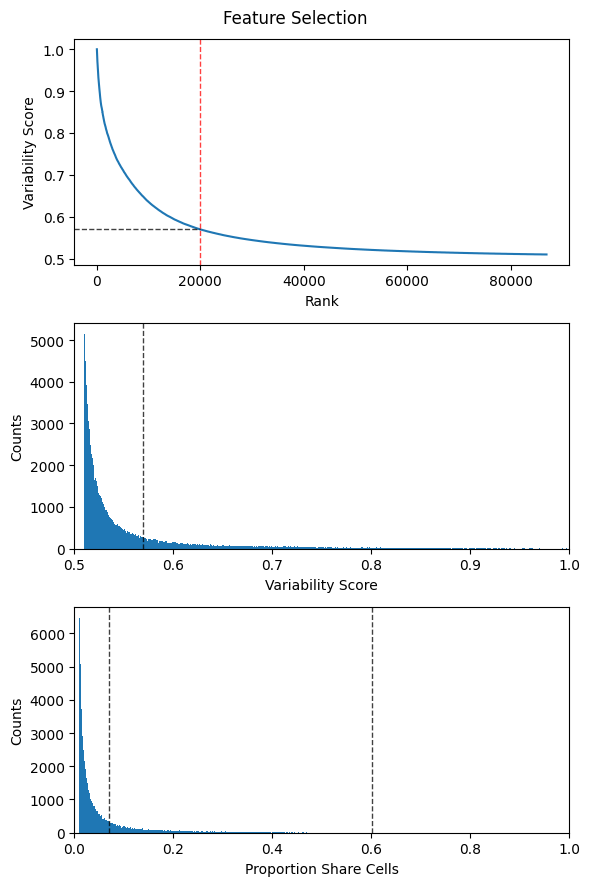

AnnData object with n_obs × n_vars = 11137 × 86915
    obs: 'idx_rna', 'idx_atac', 'sample_type', 'batch', 'stim', 'protein_MS1', 'rna_MS1', 'peaks.MS', 'predicted.celltype.l1', 'idx_adt', 'majority_votin', 'majority_voting', 'nb_features', 'n_counts'
    var: 'GeneID', 'Gene Symbol', 'Type', 'chr', 'start', 'end', 'len', 'star', 'idx', 'n_cells', 'modality', 'gene_stable_id', 'prop_shared_cells', 'variability_score', 'highly_variable', 'mean', 'std'
    uns: 'log1p', 'pca', 'neighbors', 'umap'
    obsm: 'protein_expression', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [11]:
atac = preprocessing_atac(atac)
atac

# Protein layer stable IDs

In [12]:
prot_gene_stable_id = ['ENSG00000121594',
'ENSG00000114013',
'ENSG00000120217',
'ENSG00000197646',
'ENSG00000160223',
'ENSG00000169896',
'ENSG00000168961',
'ENSG00000157873',
'ENSG00000169442',
'ENSG00000073008',
'ENSG00000130202',
'ENSG00000196776',
'ENSG00000125726',
'ENSG00000120949',
'ENSG00000117091',
'ENSG00000101017',
'ENSG00000102245',
'ENSG00000169442',
'ENSG00000261371',
'ENSG00000010610',
'{"ENSG00000153563", "ENSG00000172116"}',
'ENSG00000149294',
'ENSG00000081237',
'ENSG00000143226',
'ENSG00000177455',
'ENSG00000140678',
'ENSG00000174059',
'ENSG00000115884',
'ENSG00000048462',
'ENSG00000154096',
'ENSG00000157404',
'ENSG00000081237',
'ENSG00000185291',
'ENSG00000106991',
'ENSG00000101000',
'ENSG00000183813',
'ENSG00000010610',
'ENSG00000026508',
'ENSG00000153563',
'ENSG00000170458',
'ENSG00000203747',
'ENSG00000149294',
'ENSG00000134460',
'ENSG00000081237',
'ENSG00000188389',
'ENSG00000211893',
'ENSG00000156738',
'ENSG00000189430',
'ENSG00000183134',
'ENSG00000261371',
'ENSG00000026508',
'ENSG00000007062',
'ENSG00000162493',
'ENSG00000134853',
'ENSG00000113721',
'ENSG00000140937',
'ENSG00000141736',
'ENSG00000076706',
'ENSG00000039068',
'ENSG00000211899',
'ENSG00000211689',
'ENSG00000160791',
'ENSG00000112486',
'ENSG00000160683',
'ENSG00000083457',
'ENSG00000110848',
'ENSG00000111796',
'ENSG00000163599',
'ENSG00000089692',
'ENSG00000139193',
'ENSG00000185896',
'ENSG00000026103',
'ENSG00000186827',
'ENSG00000204287',
'ENSG00000158481',
'ENSG00000169896',
'ENSG00000150337',
'ENSG00000178726',
'ENSG00000213809',
'ENSG00000124469',
'ENSG00000203710',
'ENSG00000109956',
'ENSG00000135077',
'ENSG00000163600',
'ENSG00000153283',
'ENSG00000138185',
'ENSG00000117560',
'ENSG00000168329',
'ENSG00000272398',
'ENSG00000117322',
'ENSG00000007312',
'ENSG00000079385',
'ENSG00000122223',
'ENSG00000179776',
'ENSG00000105366',
'ENSG00000260314',
'ENSG00000088827',
'ENSG00000197992',
'ENSG00000173578',
'ENSG00000148400',
'ENSG00000139626',
'ENSG00000129226',
'ENSG00000185245',
'ENSG00000090339',
'ENSG00000174175',
'ENSG00000027697',
'ENSG00000211751',
'ENSG00000074181',
'ENSG00000129226',
np.nan,
'ENSG00000121807',
'ENSG00000108622',
'ENSG00000162692',
'ENSG00000007908',
'ENSG00000122025',
'ENSG00000005961',
'ENSG00000049249',
'ENSG00000197471',
'ENSG00000177575',
'ENSG00000112149',
'ENSG00000186891',
'ENSG00000085063',
'ENSG00000128052',
'ENSG00000077238',
'ENSG00000166825',
'ENSG00000116824',
'ENSG00000150093',
'ENSG00000198178',
'ENSG00000164171',
'ENSG00000259207',
'ENSG00000110651',
'ENSG00000168003',
'ENSG00000204936',
'ENSG00000196352',
'ENSG00000211898',
'ENSG00000160255',
'ENSG00000178562',
'ENSG00000145777',
'ENSG00000004468',
'ENSG00000168685',
'ENSG00000081237',
'ENSG00000196371',
'ENSG00000012124',
'ENSG00000072274',
'ENSG00000134258',
'ENSG00000197635',
'ENSG00000038945',
'ENSG00000179776',
'ENSG00000132514',
'ENSG00000158477',
'ENSG00000116031',
'ENSG00000135404',
'ENSG00000136869',
'ENSG00000099250',
'ENSG00000135218',
'ENSG00000004468',
'ENSG00000085563',
'ENSG00000137101',
'ENSG00000163749',
'ENSG00000153208',
'ENSG00000198910',
'ENSG00000170558',
'ENSG00000125810',
'ENSG00000091972',
'ENSG00000118777',
'ENSG00000170180',
'ENSG00000213949',
'ENSG00000115232',
'ENSG00000135318',
'ENSG00000105369',
'ENSG00000010278',
'ENSG00000282506',
'{"ENSG00000226660", "ENSG00000282568"}', 
np.nan,
'ENSG00000124731',
'ENSG00000120156',
'ENSG00000276163',
'ENSG00000113083',
'ENSG00000172116',
'ENSG00000154269',
'ENSG00000007062',
'ENSG00000090659',
'ENSG00000117400',
'ENSG00000284426',
'ENSG00000274143',
'ENSG00000204475',
'ENSG00000121858',
'ENSG00000172215',
'ENSG00000150637',
'ENSG00000054219',
'ENSG00000184451',
'ENSG00000064300',
'ENSG00000156535',
'ENSG00000005844',
'ENSG00000160712',
'ENSG00000134352',
'ENSG00000135535',
'ENSG00000117525',
'ENSG00000160856 ',
'ENSG00000163518',
'ENSG00000143297',
'ENSG00000026751',
'ENSG00000115884',
'ENSG00000177455',
'ENSG00000081237',
'{"ENSG00000292348", "ENSG00000002586"}',
'ENSG00000172322',
'ENSG00000117335',
'ENSG00000037280',
'ENSG00000165682']

In [13]:
prot = ad.AnnData(X=adata.obsm["protein_expression"].to_numpy(), var=pd.DataFrame(index=adata.obsm["protein_expression"].columns, data={"gene_stable_id": prot_gene_stable_id}), obs=adata.obs)

In [14]:
prot = preprocessing_prot(prot)
prot

AnnData object with n_obs × n_vars = 11137 × 210
    obs: 'idx_rna', 'idx_atac', 'sample_type', 'batch', 'stim', 'protein_MS1', 'rna_MS1', 'peaks.MS', 'predicted.celltype.l1', 'idx_adt', 'majority_votin', 'majority_voting'
    var: 'gene_stable_id'
    uns: 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

# Create MuData and save

In [15]:
mdata = mu.MuData({"rna": rna, 
                   "atac": atac, 
                   "prot": prot})

In [16]:
mu.pp.intersect_obs(mdata)

In [17]:
mdata.write("./data/dogma.h5mu")